# Synthetic Schedules Generation

In [3]:
from pathlib import Path

import pandas as pd

from caveat.data.synth import ActivityGen
from caveat.data.utils import generate_population, trace_to_pam
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.describe.transitions import sequence_prob_plot

In [4]:
write_path = Path("tmp/synthetic_population.csv")

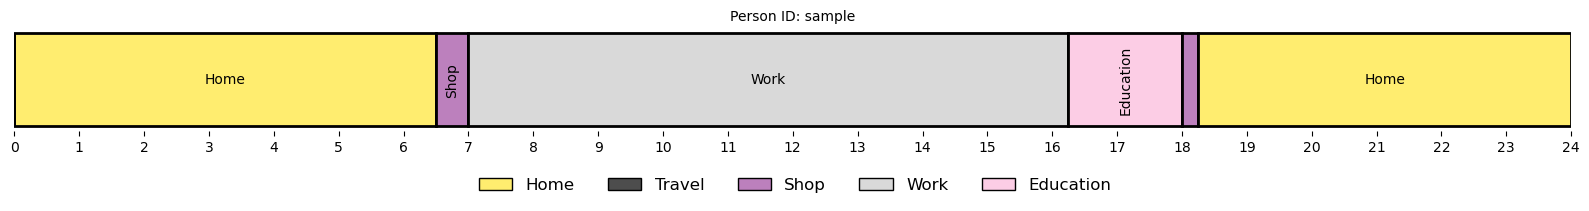

In [5]:
# Example
generator = ActivityGen()
generator.build()

trace = generator.run()
plan = trace_to_pam(trace, generator.map)
plan.plot()

In [6]:
population = generate_population(gen=generator, size=100)
population.act = population.act.map(generator.map)
population = population[["pid", "act", "start", "end", "duration"]]
population

,pid,act,start,end,duration
0,0,home,0,375,375
1,0,work,375,795,420
2,0,education,795,1005,210
3,0,home,1005,1440,435
4,1,home,0,375,375
...,...,...,...,...,...
491,99,home,0,375,375
492,99,shop,375,405,30
493,99,work,405,825,420
494,99,shop,825,960,135


In [7]:
write_path.parent.mkdir(exist_ok=True)
population.to_csv(write_path, index=False)

In [8]:
def describe_col(population, col: str) -> pd.DataFrame:
    description = population.groupby("act")[col].describe()[
        ["count", "mean", "std", "min", "max"]
    ]
    description["attribute"] = col
    return description


def describe_cols(population, cols: list[str]) -> pd.DataFrame:
    description = pd.concat(
        [describe_col(population, c) for c in cols], ignore_index=False
    )
    description = description.reset_index().set_index(["attribute", "act"])
    return description


describe_cols(population, ["start", "end", "duration"]).round()

count    mean    std    min     max
attribute act                                           
start     education   32.0   908.0   87.0  795.0   990.0
          home       216.0   555.0  521.0    0.0  1260.0
          leisure     56.0   829.0  302.0  375.0  1155.0
          shop        92.0   569.0  258.0  375.0  1020.0
          work       100.0   412.0   27.0  375.0   480.0
end       education   32.0  1039.0   42.0  990.0  1080.0
          home       216.0   928.0  512.0  375.0  1440.0
          leisure     56.0   911.0  321.0  405.0  1260.0
          shop        92.0   608.0  265.0  390.0  1035.0
          work       100.0   922.0   75.0  795.0  1020.0
duration  education   32.0   131.0   50.0   90.0   210.0
          home       216.0   373.0   71.0  180.0   480.0
          leisure     56.0    81.0   35.0   30.0   150.0
          shop        92.0    39.0   33.0   15.0   135.0
          work       100.0   511.0   69.0  420.0   615.0

In [9]:
def time_distributions(population: pd.DataFrame, mapping: dict):
    starts = {k: [] for k in mapping.values()}
    ends = {k: [] for k in mapping.values()}
    durations = {k: [] for k in mapping.values()}
    for act, acts in population.groupby("act"):
        starts[act] = list(acts.start)
        ends[act] = list(acts.end)
        durations[act] = list(acts.duration)
    return starts, ends, durations

In [10]:
starts, ends, durations = time_distributions(population, generator.map)

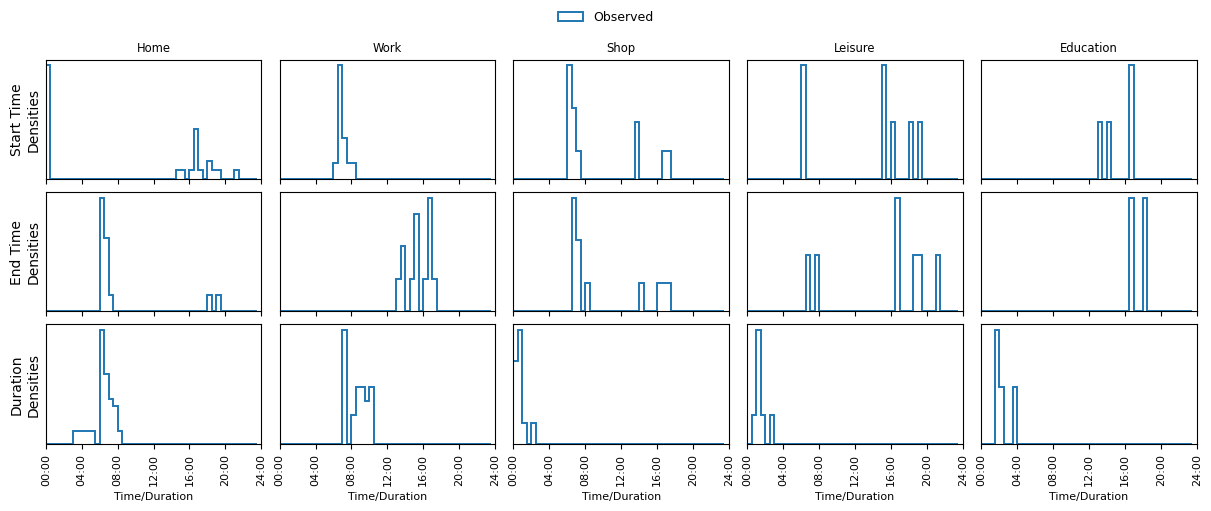

In [11]:
_ = times_distributions_plot(population, ys={})

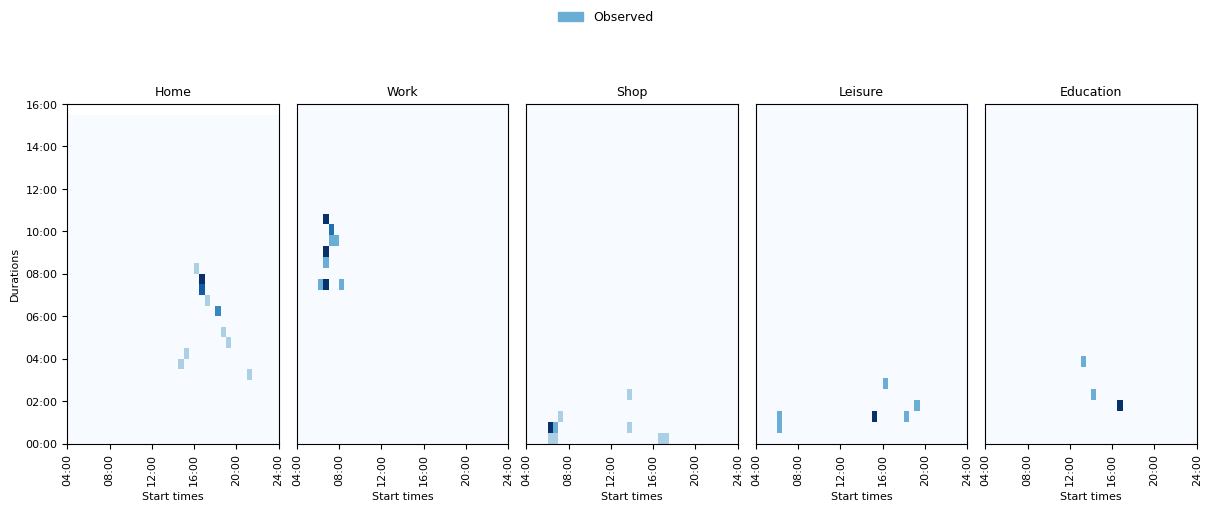

In [12]:
_ = joint_time_distributions_plot(population, ys={})

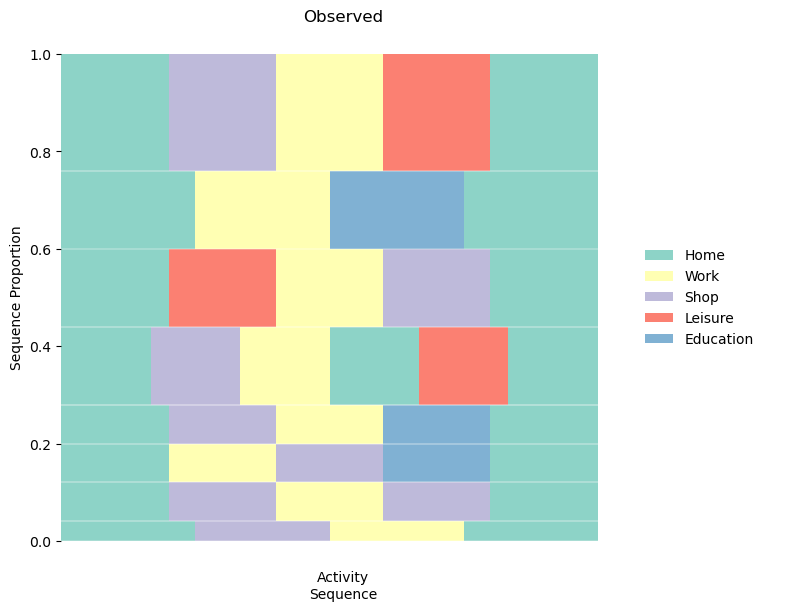

In [13]:
_ = sequence_prob_plot(population, ys={}, figsize=(8, 6))